[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


--- Basic Metadata Statistics ---
            count       mean        std   min    25%   50%   75%    max
char_count  202.0  79.534653  18.035931  38.0  69.25  82.0  92.0  128.0
word_count  202.0  11.504950   3.058708   5.0   9.00  12.0  14.0   22.0


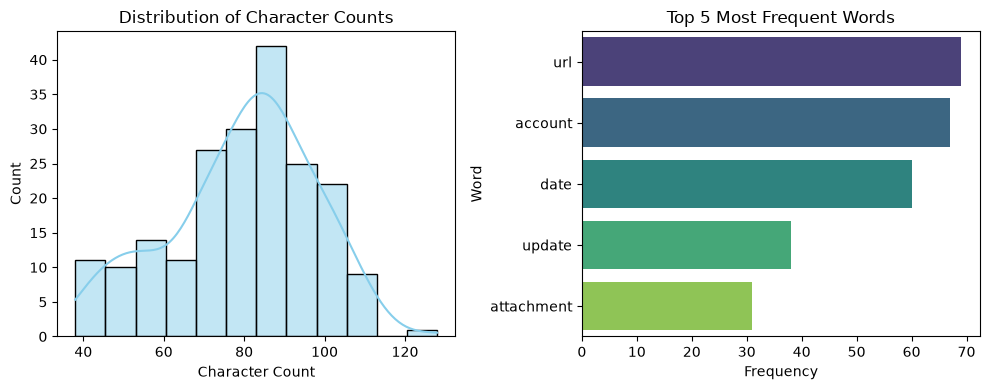


--- Top 3 Most Frequent Bigrams ---
attachment account: 8
account url: 7
url free: 7


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Setup Mock Dataset
df = pd.read_csv("../../data/preprocessed/silver/example_dataset.csv")

# 2. Text Metadata Extraction
# Calculate character length and word count per entry
df['char_count'] = df['Masked_Text'].apply(len)
df['word_count'] = df['Masked_Text'].apply(lambda x: len(x.split()))

print("--- Basic Metadata Statistics ---")
print(df[['char_count', 'word_count']].describe().T)

# 3. Text Preprocessing for Frequency Analysis
def clean_and_tokenize(text):
    # Convert to lowercase and tokenize words
    tokens = nltk.word_tokenize(text.lower())
    # Remove punctuation and English stop words
    stop_words = set(stopwords.words('english'))
    cleaned = [word for word in tokens if word.isalnum() and word not in stop_words]
    return cleaned

# Apply cleaning
df['cleaned_tokens'] = df['Masked_Text'].apply(clean_and_tokenize)

# Flatten list of all words across all documents
all_words = [word for tokens in df['cleaned_tokens'] for word in tokens]

# 4. Plot Top Unigrams (Most Common Individual Words)
word_counts = Counter(all_words)
top_words_df = pd.DataFrame(word_counts.most_common(5), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 4))

# Subplot 1: Distribution of Text Character Counts
plt.subplot(1, 2, 1)
sns.histplot(df['char_count'], kde=True, color='skyblue')
plt.title('Distribution of Character Counts')
plt.xlabel('Character Count')

# Subplot 2: Bar Plot of Top Words
plt.subplot(1, 2, 2)
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis', hue='Word', legend=False)
plt.title('Top 5 Most Frequent Words')

plt.tight_layout()
plt.show()

# 5. N-gram Analysis (Bigrams)
# Generate pairs of consecutive words to capture basic context
all_bigrams = list(ngrams(all_words, 2))
bigram_counts = Counter(all_bigrams)

print("\n--- Top 3 Most Frequent Bigrams ---")
for bigram, freq in bigram_counts.most_common(3):
    print(f"{bigram[0]} {bigram[1]}: {freq}")


In [5]:
df

,label,Full Text,Masked_Text,char_count,word_count,cleaned_tokens
0,phishing,Urgent: Account Verification Required \n\n You...,Urgent: Account Verification Required \n\n You...,101,16,"[urgent, account, verification, required, acco..."
1,phishing,Invoice #3921 Overdue \n\n Your payment is ove...,Invoice #3921 Overdue \n\n Your payment is ove...,98,12,"[invoice, 3921, overdue, payment, overdue, dow..."
2,phishing,Unusual Activity Detected \n\n Suspicious logi...,Unusual Activity Detected \n\n Suspicious logi...,84,11,"[unusual, activity, detected, suspicious, logi..."
3,phishing,Tax Refund Processing Error \n\n Your refund i...,Tax Refund Processing Error \n\n Your refund i...,79,12,"[tax, refund, processing, error, refund, delay..."
4,phishing,Your Package Awaits! \n\n Delivery issue detec...,Your Package Awaits! \n\n Delivery issue detec...,102,11,"[package, awaits, delivery, issue, detected, u..."
...,...,...,...,...,...,...
197,benign,Backup Completed \n\n Your files were backed u...,Backup Completed \n\n Your files were backed u...,80,11,"[backup, completed, files, backed, successfull..."
198,benign,Plan Upgrade Confirmation \n\n Your plan was u...,Plan Upgrade Confirmation \n\n Your plan was u...,77,11,"[plan, upgrade, confirmation, plan, upgraded, ..."
199,benign,Customer Survey \n\n Share feedback on your re...,Customer Survey \n\n Share feedback on your re...,75,11,"[customer, survey, share, feedback, recent, pu..."
200,phishing,Your account don.matrick@gmail.com has been ha...,Your account [EMAIL_ADDRESS] has been hacked! ...,111,17,"[account, hacked, go, website, url, login, res..."
